In [1]:
# illustrative example of use VeraRubin 

## Creating a Local Butler for a Selected Set of Visits

> Version: 1.0
> Container Size: Large

> Description: In this notebook, we present illustrative examples of using Vera Rubin’s functions to create a local Butler for a chosen set of visits.

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

!python --version

Release r30.0.10 (RSP Build 2991)
lsst_distrib          gdfb3db0272+4407f27008 	current o_latest v30_0_10 v30_0_10_rc4 setup
Python 3.13.9


In [3]:
%load_ext autoreload
%autoreload

In [4]:
import numpy as np
import VeraRubin as vr
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler

### Loading the butler and show some information

In [5]:
# Initialize Butler
COLLECTION = "LSSTComCam/DP1"
REPOSITORY = "dp1"

butler = Butler(config=REPOSITORY, collections=COLLECTION)
assert butler is not None

## Identify visit images around location

In [13]:
# Identify visit images around location
ra_deg, dec_deg = (52.9904715 , -28.3993699) # (53.2, -27.8)
loc_data = ra_deg, dec_deg

bands = ['u', 'i']

visit_name = "visit_image"
print(f"Using -> {visit_name}")

visits_image_selected_list = {}
for band in bands:
    visit_refs = vr.visit_dataset(butler, band, loc_data, use_patch_area=False, detectors=None, timespan=None, visit_ids=None)
    print(f'[INF] Found {len(visit_refs)} visits in band {band}')
    visits_image_selected_list[band] = visit_refs  # Saving the visit data set per band

Using -> visit_image
[INF] Found 24 visits in band u
[INF] Found 96 visits in band i


## Creating the local butler repository and copying the visits

In [ ]:
# General CONFIGURATION
LOCAL_REPO = "./local_butler"       # Local butler repo path (relative to this notebook, inside examples/)
REMOTE_REPO = vr.get_butler_location(butler)  # Remote butler repo path
COLLECTION = "LSSTComCam/DP1"

In [15]:
# taking the first four
nbest = 10

visits_u = visits_image_selected_list['u'][:nbest]
visits_i = visits_image_selected_list['i'][:nbest]

In [10]:
def make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits):
    # Make the object/Setup logging directory and logger
    lbutler = vr.LocalButler(local_repo=LOCAL_REPO, remote_repo=REMOTE_REPO, LOGDIR=LOCAL_REPO+"/logs")

    # Creating an empty butler
    lbutler.make_repo()

    # Register instruments (collect unique instrument names from DatasetRefs)
    lbutler.reg_instruments(visits_u, remote_collection=COLLECTION)

    # Registering SkyMap DatasetType and copying skyMap dataset(s) (preserving UUIDs)
    lbutler.reg_transfer_skyMap(remote_collection=COLLECTION)

    # transfer some datasets associated to "visit_image"
    for visits in data_visits:
        lbutler.discover_transfer_datasets(visits, remote_collection=COLLECTION)

    # Finally, create a chained collection
    lbutler.chained(chain_name="local_main_chain")

    return True

In [10]:
# Making the local butler
data_visits = [visits_u, visits_i]

make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits)

2026-08-17 15:18:32 [INFO] Created LOGDIR at ./local_butler/logs


2026-08-17 15:18:32 [INFO] Starting pipeline for local repo: ./local_butler


2026-08-17 15:18:32 [INFO] Creating Butler repo at ./local_butler


2026-08-17 15:18:33 [INFO] Registering instruments: ['LSSTComCam']


2026-08-17 15:18:33 [INFO] Detected instruments to register: ['LSSTComCam']


...

2026-08-17 15:24:23 [INFO] Making a chained collection


2026-08-17 15:24:23 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-08-17 15:24:23 [INFO] Registered CHAINED collection: local_main_chain


2026-08-17 15:24:23 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


True

## Visualizing some local butler's information

In [11]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
skymaps                                                     RUN    


In [12]:
# Dataset types
print("List of avalibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of avalibles datasetType:
     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [13]:
# Skymap collection
print("List of avalibles Skymaps:")
!butler query-datasets $LOCAL_REPO skyMap --collections skymaps

List of avalibles Skymaps:

 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [14]:
# identifying the RUN name of visit_summary
!butler query-datasets $LOCAL_REPO visit_summary \
  --collections local_main_chain \
  --limit 5


     type                                run                                             id                  instrument     visit     band day_obs  physical_filter
------------- --------------------------------------------------------- ------------------------------------ ---------- ------------- ---- -------- ---------------
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z a8cc9060-4937-4aec-99b1-d567cbea3598 LSSTComCam 2024110900197    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 89fbcba3-ec7b-40c7-b6b9-217af5cab113 LSSTComCam 2024110900199    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 1fb4efd7-9d61-4730-a037-78fd6ff624b2 LSSTComCam 2024110900203    u 20241109            u_02
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 7aac5784-b4f2-450d-bc94-951defe84b10 LSSTComCam 2024110900204    u 20241109            u_02
visit_summary L

## Stamp Injection

In this example, we perform the injection and simultaneously store the new (stamp-injected) visit_image in the butler. For an example where the new (stamp-injected) visit_image is already provided, see the `vr_injection_example notebook`.

In [15]:
# First: we need to create a new RUN and a CHAIN with only the skymap and visit_summary, because we preserved the dataId of the visits.
# IMPORTANT: if the RUN exists, we jump this step

# Adding the new RUN/CHAIN
members = ['skymaps',
           'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z'  # visit_summary
          ]


run_name = "direct_injected_run"
chain_name = "local_with_injection"
vr.ensure_chained_collection(local_repo=LOCAL_REPO, 
                             run_name=run_name,
                             chain_name=chain_name,
                             members=members)

True

In [16]:
# Notice as appear a new Collections

print("List of avalibles colections:")
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
  direct_injected_

In [11]:
def random_position(REPO, collection, skymap_name, loc, num):
    """
    Generate `num` random RA/Dec positions inside the patch corresponding
    to the sky location `loc = (ra_deg, dec_deg)`, including loc.
    """
    import lsst.geom as geom

    ra_deg, dec_deg = loc
    if num == 1: return [ra_deg], [dec_deg]
    point_sky = geom.SpherePoint(ra_deg, dec_deg, geom.degrees)
    
    butler = Butler(REPO, collections=collection)
    sky_map = butler.get("skyMap", skymap=skymap_name)

    tract_info = sky_map.findTract(point_sky)
    patch_info = tract_info.findPatch(point_sky)

    bbox = patch_info.getOuterBBox()
    wcs = tract_info.getWcs()
    
    xmin, ymin = bbox.getMin()
    xmax, ymax = bbox.getMax()

    x = np.random.uniform(xmin, xmax, num - 1)
    y = np.random.uniform(ymin, ymax, num - 1)

    ra_list, dec_list = [ra_deg], [dec_deg]
    for xi, yi in zip(x, y):
        sky = wcs.pixelToSky(geom.Point2D(xi, yi))
        ra_list.append(sky.getRa().asDegrees())
        dec_list.append(sky.getDec().asDegrees())

    return ra_list, dec_list

In [16]:
# Second: we make the injection of the stamp/s and put the results in our butler

# Defining the sky coordinates and the selected band
ra_deg, dec_deg = (53.2, -27.8)
loc_data = (ra_deg, dec_deg)
bands = 'ui'
visits = {'u': visits_u, 'i': visits_i}

# Opening the FITS file
stamp_paths = ['stamp/test.fits']
               #'stamp/test.fits',
               #'stamp/test.fits'
              #]

# Defining the properties of the stamp
mags = [14.8]#, 14.8, 14.8]  # Magnitude used to inject the stamp

# Sky position of the injection
ra_list, dec_list = random_position(LOCAL_REPO,
                                    collection='local_main_chain',
                                    skymap_name="lsst_cells_v1",
                                    loc=loc_data, num=len(stamp_paths))

In [21]:
# Injecting
injected_exposure_data = []
for band in bands:
    injected_exposure = vr.main_inject_stamp(
        REPO=REMOTE_REPO, # alternatively we can use LOCAL_REPO,
        collections="LSSTComCam/DP1",  # alternatively we can use "local_main_chain",
        visit_ids=[visit.dataId["visit"] for visit in visits[band]],  # use in case of a remote repo is choose
        loc=loc_data,
        band=band,
        stamp_paths=stamp_paths,
        mags=mags,
        ra_list=ra_list,
        dec_list=dec_list,    
        REPO_SAVE=LOCAL_REPO,  # important to save directly on the butler 
        collection_save=chain_name,  # important to save directly on the butler 
        run_name_save=run_name,  # important to save directly on the butler 
        update_wcs=False,
        info_save_path=None,
        rot_name_save="test/stamp_rotated",
        remove_rotated_stamps=True,
        info=True)

    injected_exposure_data.append(injected_exposure)

[INFO] Loading the butler...
[INFO] Injection on sky coordinates: RA=53.2, Dec=-27.8
[INFO] Found 5 visits for band=u
END: Collect visit exposures and getWcs info
Execution time: 13.141 seconds
[INFO] Using 5 visits after sorting and selection.
[INFO] Computed 5 rotation angles.


[SKIP] visit 2024113000172 already exists.


[SKIP] visit 2024110900203 already exists.


[SKIP] visit 2024110900217 already exists.


[SKIP] visit 2024110900199 already exists.


...

[SKIP] visit 2024111100076 already exists.


[SKIP] visit 2024110800261 already exists.


[SKIP] visit 2024111100074 already exists.


[SKIP] visit 2024110800297 already exists.


[SKIP] visit 2024110800260 already exists.
[INFO] Injection complete.


In [22]:
# Validating
!butler query-datasets $LOCAL_REPO visit_image \
  --collections $chain_name \
  --limit 5


    type            run                          id                  instrument detector     visit     band day_obs  physical_filter
----------- ------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image direct_injected_run 01a01056-0392-7685-a4c3-b593d259af13 LSSTComCam        8 2024110900199    u 20241109            u_02
visit_image direct_injected_run 01a01055-dd57-71e7-a7b3-21601de64247 LSSTComCam        2 2024110900203    u 20241109            u_02
visit_image direct_injected_run 01a01056-161f-7247-ad40-6bba03fd5fcc LSSTComCam        5 2024110900204    u 20241109            u_02
visit_image direct_injected_run 01a01055-f0e5-7798-9b85-42ae476c82a4 LSSTComCam        8 2024110900217    u 20241109            u_02
visit_image direct_injected_run 01a01055-c835-7ddf-9482-c8517c46cf80 LSSTComCam        0 2024113000172    u 20241130            u_02



## Plot the result

In [23]:
lbutler = Butler(LOCAL_REPO, collections='local_main_chain') 

inj_lbutler = Butler(LOCAL_REPO, collections='local_with_injection') 

In [24]:
# extracting visits
refs_inj_visit = inj_lbutler.query_datasets("visit_image")

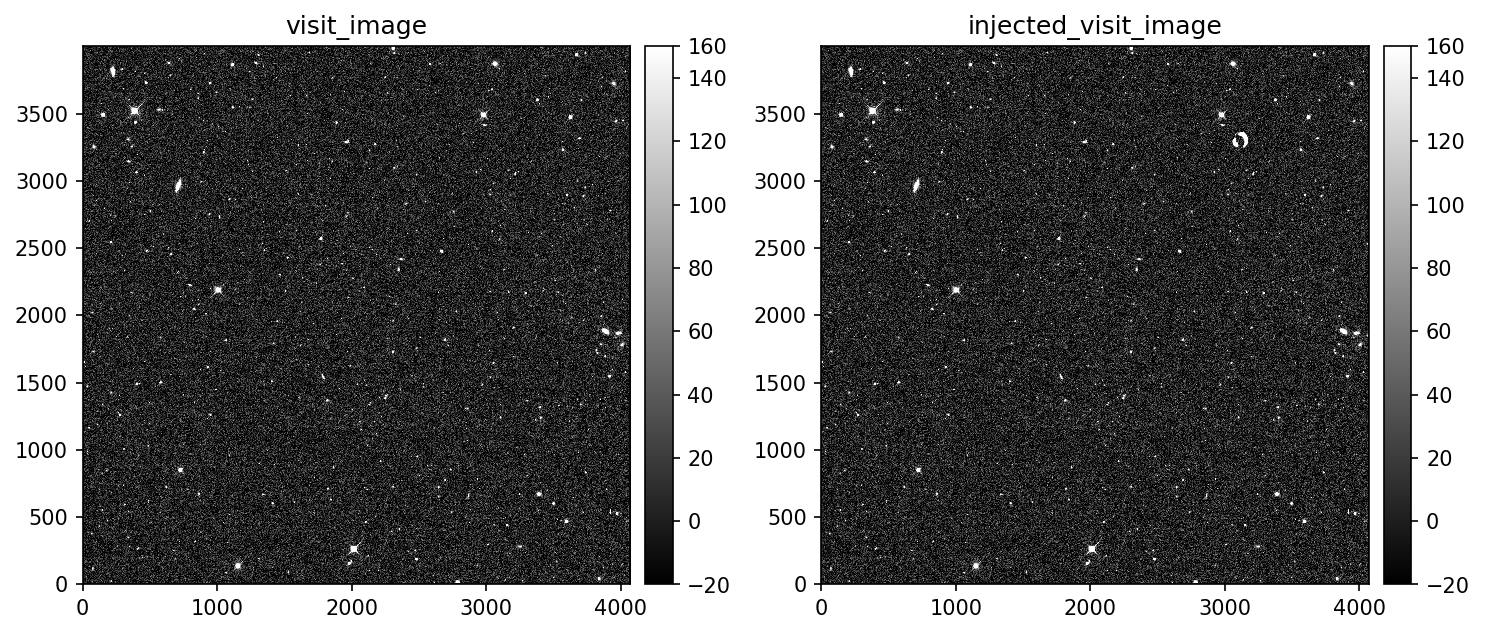

In [25]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")

num = 3
visit_img = lbutler.get('visit_image', dataId=refs_inj_visit[num].dataId)
plot_injected_img = inj_lbutler.get('visit_image', dataId=refs_inj_visit[num].dataId)

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(visit_img.image)
plt.title('visit_image')

plt.sca(ax[1])
display1 = afwDisplay.Display(frame=fig)
# display1.scale('linear', 'zscale')
display1.scale('linear', min=-20, max=150)
display1.mtv(plot_injected_img.image)
# To zoom on the PGC 038749 stamp:
# display1.mtv(plot_injected_img.image[1700:2200, 1950:2450])
plt.title('injected_visit_image')

plt.tight_layout()
plt.show()

### Making a deep coadd

In [26]:
import pandas as pd

In [27]:
refs = inj_lbutler.query_datasets("visit_image")

visits_selected = {'visit_id': [], 'band': []}
for ref in refs:
    visits_selected['visit_id'].append(ref.dataId.get('visit'))
    visits_selected['band'].append(ref.dataId.get('band'))

pd_visits_selected = pd.DataFrame(visits_selected)

In [28]:
# pd_visits_selected

In [29]:
# Identify visit images around location
loc_data = ra_deg, dec_deg

In [30]:
vr.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection=chain_name,
                          my_collection_name='custom_coadd',
                          sky_coordinates=True,
                          SAVE_FITS=False,
                          out=False)

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/pipe_base/g954f02917a+b900f87b66/python/lsst/pipe/base/simple_pipeline_executor.py:457: FutureWarning: Call to deprecated class SimplePipelineExecutor. (The SimplePipelineExecutor class has moved to lsst.pipe.base.simple_pipeline_executor. This forwarding shim will be removed after v30.) -- Deprecated since version v30.
  return cls(


[INFO] Metadata saved: ./local_butler/custom_coadd_info.txt


In [31]:
# some checks
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd                                                CHAINED
  custom_coadd/20260817T153932Z                             RUN    
  custom_coadd/inputs                                       TAGGED 
custom_coadd/20260817T152915Z                               RUN    
custom_coadd/20260817T153543Z                               RUN    
custom_coadd/20260817T153932Z                               RUN    
custom_coadd/inputs                                         TAGGED 
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                       

In [32]:
!butler query-dataset-types $LOCAL_REPO --collections custom_coadd

             name             
------------------------------
assembleDeepCoadd_config      
assembleDeepCoadd_log         
assembleDeepCoadd_metadata    
compare_warp_artifact_mask    
deep_coadd_input_map          
deep_coadd_n_image            
deep_coadd_predetection       
deep_coadd_visit_selection    
direct_warp                   
direct_warp_masked_fraction   
makeDirectWarp_config         
makeDirectWarp_log            
makeDirectWarp_metadata       
makePsfMatchedWarp_config     
makePsfMatchedWarp_log        
makePsfMatchedWarp_metadata   
packages                      
psf_matched_warp              
selectDeepCoaddVisits_config  
selectDeepCoaddVisits_log     
selectDeepCoaddVisits_metadata
skyMap                        
visit_image                   
visit_summary                 


In [33]:
!butler query-datasets $LOCAL_REPO deep_coadd_visit_selection \
  --collections custom_coadd \
  --limit 5


           type                         run                               id                  band instrument     skymap    tract patch
-------------------------- ----------------------------- ------------------------------------ ---- ---------- ------------- ----- -----
deep_coadd_visit_selection custom_coadd/20260817T153932Z 01a01060-c776-7fbf-a490-6076061fe3f7    i LSSTComCam lsst_cells_v1  5063    34
deep_coadd_visit_selection custom_coadd/20260817T153932Z 01a01060-c776-7179-a5c8-60cde32d2421    u LSSTComCam lsst_cells_v1  5063    34



### Comparing with the full deep_coadd

In [36]:
import os
import json

In [38]:
local_repo_path = LOCAL_REPO #os.path.join(os.getenv("HOME"), LOCAL_REPO) 
info_txt_path = os.path.join(local_repo_path, "custom_coadd_info.txt")

with open(info_txt_path, "r") as f:
        info = json.load(f)

info

{'repo_path': './local_butler',
 'collection': 'custom_coadd/20260817T153932Z',
 'coadd_type': 'deep_coadd_predetection',
 'tract': 5063,
 'patch': '34',
 'bands': ['i', 'u'],
 'instrument': 'LSSTComCam',
 'skymap': 'lsst_cells_v1'}

In [39]:
lbutler = Butler(LOCAL_REPO, collections="local_main_chain")

inj_coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd') 

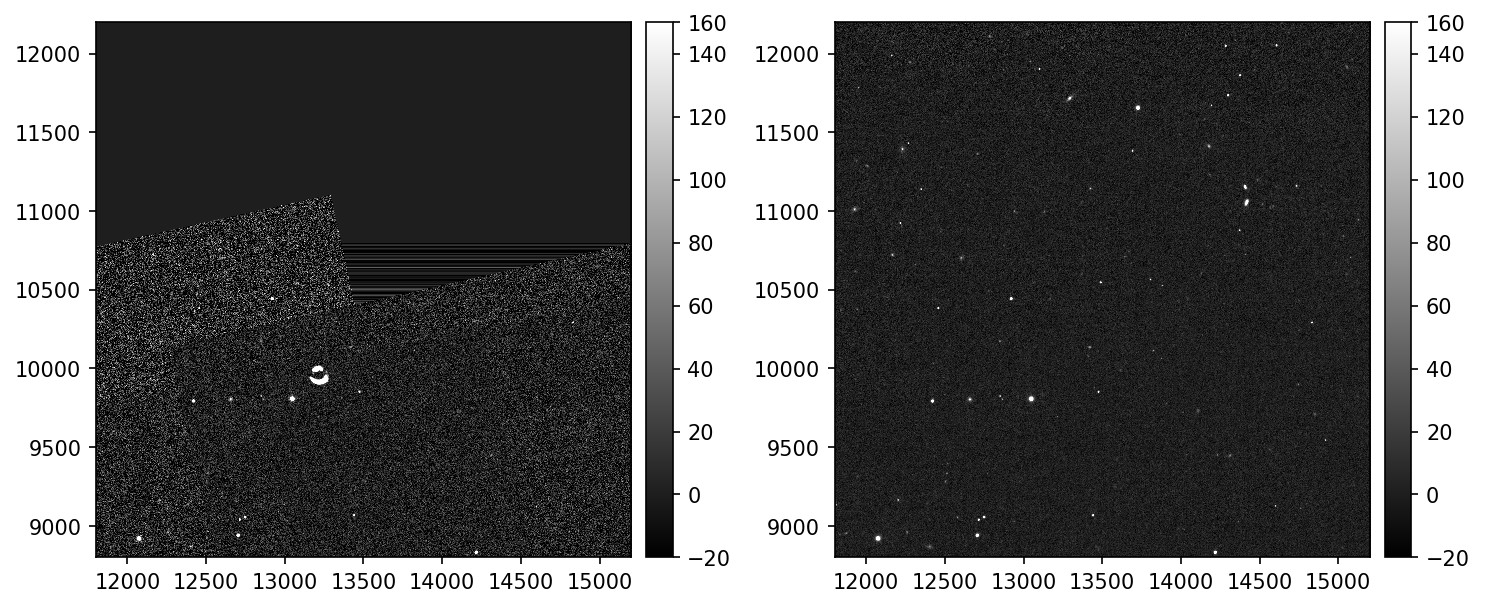

In [40]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")


coadd = lbutler.get('deep_coadd', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34})
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34})

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(inj_coadd.image)


plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd.image)

plt.tight_layout()

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/arestrada88/Alma_proyect/VeraRubin/plot/exposure_plot.py:224: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


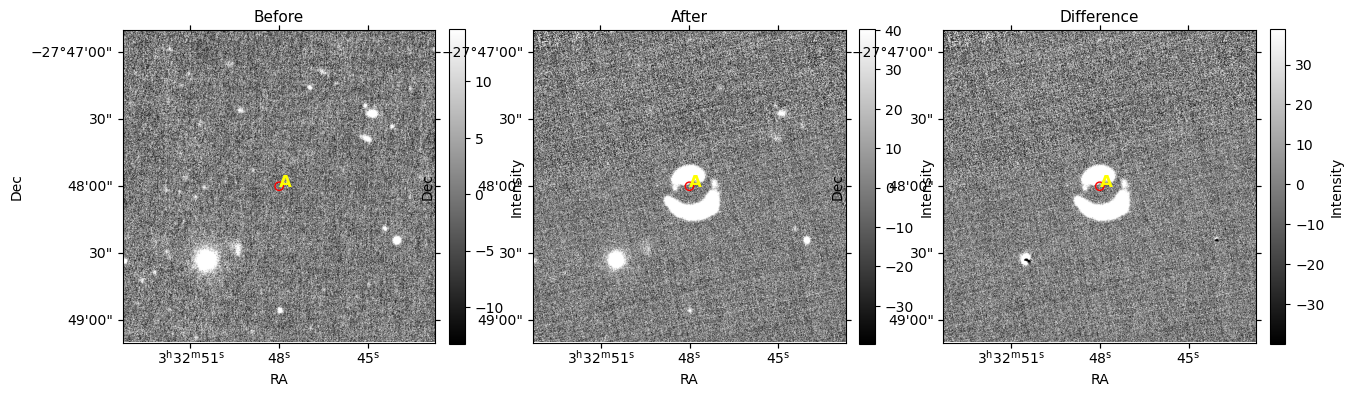

In [41]:
# Simple comparison (subtraction of both)
points = [loc_data]
before = coadd
after = inj_coadd

# necessary because the corner no is (0, 0)
bbox = after.getBBox()
xmin = bbox.getMinX()
xmax = bbox.getMaxX()
ymin = bbox.getMinY()
ymax = bbox.getMaxY()

vr.injection_steps(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=70,  # arcsec  10
                   grid=False, percentiles=[5, 95],
                   extent=[xmin, xmax, ymin, ymax])

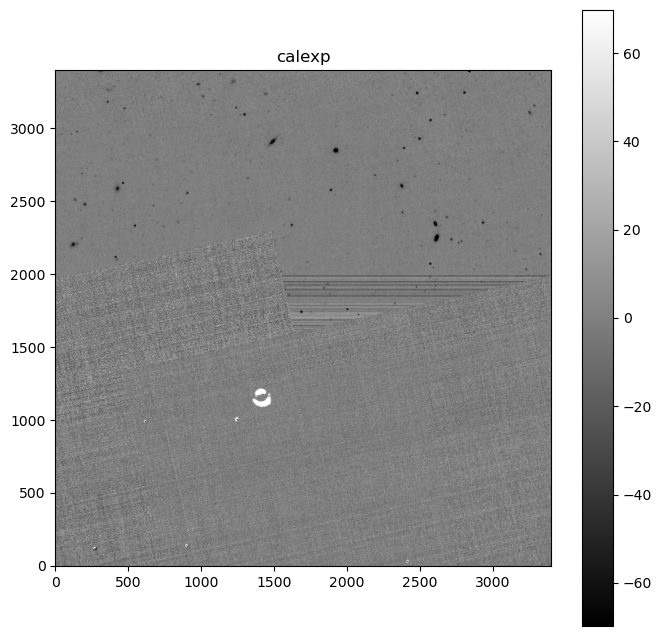

In [42]:
diff = inj_coadd.clone()
diff.image.array[:] = inj_coadd.image.array - coadd.image.array

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()

### Testing the coadd with the rotate/inject visits

In [43]:
inj_lbutler = Butler(LOCAL_REPO, collections='local_with_injection') 
inj_coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd') 

In [44]:
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection',
                                  dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34})

In [45]:
from lsst.afw.image import ExposureF, MaskedImageF
from lsst.afw.math import warpExposure, WarpingControl

# Get reference geometry and WCS
ref_exp = inj_coadd.clone()

dims = ref_exp.getMaskedImage().getDimensions()
ref_wcs = ref_exp.getWcs()
ref_bbox = ref_exp.getBBox()

In [46]:
# refs_inj_visit

In [ ]:
data_exp = []
for data in visits_u:
    exp = inj_lbutler.get('visit_image', dataId=data.dataId)
    warped_exp = ExposureF(ref_bbox, ref_wcs)
    warpExposure(warped_exp, exp, WarpingControl(warpingKernelName="lanczos3"))
    data_exp.append(warped_exp)

In [ ]:
sust_imag = np.copy(ref_exp.image.array)
for im in data_exp:
    sust_imag -=  np.nan_to_num(im.image.array, nan=0)
sust_imag = sust_imag/len(data_exp)

In [ ]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")


fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
display0.scale('linear', min=-20, max=150)
display0.mtv(ref_exp.image)

plt.sca(ax[1])
differ = ref_exp.image.array - (np.nan_to_num(data_exp[0].image.array, nan=0))
im = plt.imshow(differ, origin="lower", cmap="gray",
           vmin=np.percentile(differ, 1), #np.percentile(differ, 1),
           vmax=np.percentile(differ, 99)) # np.percentile(differ, 99)
plt.colorbar(im, aspect=5.2)

plt.tight_layout()

In [ ]:
plt.imshow(sust_imag, origin="lower", cmap="gray",
           vmin=np.percentile(sust_imag, 1),
           vmax=np.percentile(sust_imag, 99))

plt.tight_layout()

## Making a coadd with the same visit number, but without the injected stamp

In [ ]:
vr.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection="local_main_chain",  # important change the collection
                          my_collection_name='custom_coadd_without_stamp',
                          sky_coordinates=True,
                          SAVE_FITS=False,
                          out=False,
                          meta_data_name ="custom_coadd_info_without_stamp")

In [ ]:
# some checks
!butler query-collections --chains 'TREE' $LOCAL_REPO